# **Comparación del csv en el detector vs. sup**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [25]:
df_sup = pd.read_csv('/home/lurishi/Escritorio/HeavenlyMCP/Data/MCP_flux/MCP_flux/MCP_AllMesons_SURFACE_sum.csv')
df_det = pd.read_csv('/home/lurishi/Escritorio/HeavenlyMCP/Data/MCP_flux/MCP_flux/MCP_Detector_AllcosTh.csv')


In [28]:
df_sup.head()

,cos,eps2,mass,e,flux_total,flux_pi0,flux_eta,flux_rho,flux_omega,flux_phi,flux_jpsi
0,0.0,5.000000e-09,0.01,0.134970,4.641691e-12,4.641691e-12,0.000000e+00,0.0,0.0,0.0,0.0
1,0.0,5.000000e-09,0.01,0.193691,4.489728e-12,4.489728e-12,0.000000e+00,0.0,0.0,0.0,0.0
2,0.0,5.000000e-09,0.01,0.277960,2.835093e-12,2.835093e-12,0.000000e+00,0.0,0.0,0.0,0.0
3,0.0,5.000000e-09,0.01,0.398891,2.190507e-12,2.190507e-12,0.000000e+00,0.0,0.0,0.0,0.0
4,0.0,5.000000e-09,0.01,0.547850,1.248774e-12,8.615132e-13,3.872608e-13,0.0,0.0,0.0,0.0


In [51]:
df_det.head()

,cos,eps2,mass,e,flux
0,0.0,5.000000e-09,0.01,0.134970,1.391775e-12
1,0.0,5.000000e-09,0.01,0.161887,1.139399e-12
2,0.0,5.000000e-09,0.01,0.194172,8.394934e-13
3,0.0,5.000000e-09,0.01,0.232896,6.969535e-13
4,0.0,5.000000e-09,0.01,0.279342,5.287962e-13


In [49]:
eps2 = 1e-4
cos_theta = [0,1]
m_mcp = 0.1

flujo_sup = df_sup[(df_sup['eps2'] == eps2) & (df_sup['cos'] == cos_theta[0]) & (df_sup['mass'] == m_mcp)]['flux_total']
e_sup = df_sup[(df_sup['eps2'] == eps2) & (df_sup['cos'] == cos_theta[0]) & (df_sup['mass'] == m_mcp)]['e']
flujo_det = df_det[(df_det['eps2'] == eps2) & (df_det['cos'] == -1) & (df_det['mass'] == m_mcp)]['flux']
e_det = df_det[(df_det['eps2'] == eps2) & (df_det['cos'] == -1) & (df_det['mass'] == m_mcp)]['e']

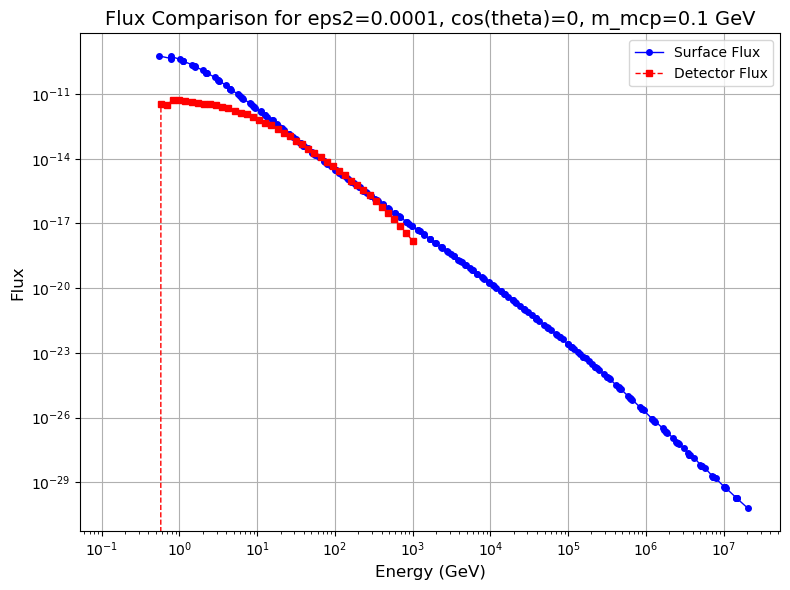

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(e_sup, flujo_sup, label='Surface Flux', color='blue', marker='o', markersize=4, linestyle='-', linewidth=1)
ax.plot(e_det, flujo_det, label='Detector Flux', color='red', marker='s', markersize=4, linestyle='--', linewidth=1)
ax.set_xlabel('Energy (GeV)', fontsize=12)
ax.set_ylabel('Flux', fontsize=12)
ax.set_title(f'Flux Comparison for eps2={eps2}, cos(theta)={cos_theta[0]}, m_mcp={m_mcp} GeV', fontsize=14)
ax.legend()
ax.grid(True)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(f'flux_comparison_eps2_{eps2}_cos_{cos_theta[0]}_mass_{m_mcp}.png', dpi=300)
plt.show()